# Figure 6

This notebook reproduces five panels. All paths are relative to the repository.

In [1]:
from pathlib import Path
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore', message='IProgress not found.*')
import shap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from PIL import Image as PILImage
from IPython.display import Image as NotebookImage, display

plt.rcParams.update({
    'figure.dpi': 500,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'data_analysis' / 'data' / 'analysis_data.xlsx').exists():
            return candidate
    raise FileNotFoundError('Could not locate data_analysis/data/analysis_data.xlsx.')

ROOT = find_repository_root()
DATA_FILE = ROOT / 'data_analysis' / 'data' / 'analysis_data.xlsx'
FIGURE_DIR = ROOT / 'data_analysis' / 'outputs' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print('Repository root:', ROOT)


Repository root: C:\Users\zh509\OneDrive - University of Illinois - Urbana\A\P5 collab LCML\Chiral-LLC-ML-main


In [2]:
feature_table = pd.read_excel(DATA_FILE, sheet_name='Exp_ML_features')
metadata_table = pd.read_excel(DATA_FILE, sheet_name='Exp_ML_metadata')
if not feature_table['experiment_id'].equals(metadata_table['experiment_id']):
    raise ValueError('Exp_ML_features and Exp_ML_metadata are not aligned by experiment_id.')
if feature_table['experiment_id'].duplicated().any() or len(feature_table) != 773:
    raise ValueError('Expected 773 uniquely keyed experimental rows.')

features_all = feature_table.drop(columns='experiment_id').reset_index(drop=True)
metadata = metadata_table[['abs_g_factor', 'family', 'polymer']].rename(columns={
    'family': 'Family', 'polymer': 'Polymer'
}).reset_index(drop=True)
rowmap = pd.DataFrame({
    'RowPos': np.arange(len(metadata_table)),
    'Family': metadata_table['family'],
    'Polymer name': metadata_table['polymer'],
    'Solvent': metadata_table['solvent'],
    'Assemble Type': metadata_table['assembly_type'],
    'Temperature': metadata_table['temperature_C'],
    'Concentration_mg_mL': metadata_table['concentration_mg_mL'],
})

family_columns = [column for column in features_all if column.startswith('family_')]
if not features_all[family_columns].sum(axis=1).eq(1).all():
    raise ValueError('Each experimental row must have exactly one family indicator.')
print(f'Experimental v6x data aligned: {len(features_all)} rows')


Experimental v6x data aligned: 773 rows


In [3]:
STRONG = 'Strongly Chiral'
WEAK = 'Weakly Chiral'
ISOTROPIC = 'Isotropic'
AGGREGATION = 'Aggregated'
CATEGORY_ORDER = [STRONG, WEAK, ISOTROPIC, AGGREGATION]
cmap_outcome = LinearSegmentedColormap.from_list(
    'outcome_blue_white_red', [(0, '#008BFB'), (0.5, '#FFFFFF'), (1, '#FF0051')], N=256
)
CATEGORY_TO_COLOR = {
    STRONG: cmap_outcome(0.90), WEAK: cmap_outcome(0.60),
    ISOTROPIC: cmap_outcome(0.35), AGGREGATION: cmap_outcome(0.05),
}
CATEGORY_TO_MARKER = {STRONG: 'o', WEAK: 's', ISOTROPIC: '^', AGGREGATION: 'v'}
CATEGORY_TO_ZORDER = {STRONG: 5, WEAK: 4, ISOTROPIC: 3, AGGREGATION: 2}

plot_df = pd.DataFrame({
    'RowPos': np.arange(len(features_all)),
    'FASTSOLV_monomer': pd.to_numeric(features_all['Monomer_fastsolv'], errors='coerce'),
    'FASTSOLV_backbone': pd.to_numeric(features_all['Backbone_fastsolv'], errors='coerce'),
    'abs_g_factor': pd.to_numeric(metadata['abs_g_factor'], errors='coerce'),
    'Polymer name': rowmap['Polymer name'].to_numpy(),
    'Solvent': rowmap['Solvent'].to_numpy(),
    'Temperature': rowmap['Temperature'].to_numpy(),
    'Concentration_mg_mL': rowmap['Concentration_mg_mL'].to_numpy(),
    'Assemble Type': rowmap['Assemble Type'].to_numpy(),
})

def assign_category(assembly, g_value):
    if pd.isna(assembly) or pd.isna(g_value):
        return np.nan
    assembly = str(assembly).strip().lower()
    if assembly == 'c':
        return STRONG if g_value >= 0.001 else WEAK
    if assembly == 'i':
        return ISOTROPIC
    if assembly == 'a':
        return AGGREGATION
    return np.nan

plot_df['Category'] = [assign_category(a, g) for a, g in zip(plot_df['Assemble Type'], plot_df['abs_g_factor'])]
d_all = plot_df.dropna(subset=['FASTSOLV_monomer', 'FASTSOLV_backbone', 'Category']).copy()
d_all['_Polymer_key'] = d_all['Polymer name'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True).str.lower()
d_all['_Solvent_key'] = d_all['Solvent'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True).str.lower()

feature_columns_to_add = [c for c in features_all if c not in d_all.columns]
d_all_feature = d_all.merge(
    features_all[feature_columns_to_add].assign(RowPos=np.arange(len(features_all))),
    on='RowPos', how='left', validate='one_to_one'
)
print('Outcome counts:')
print(d_all['Category'].value_counts().reindex(CATEGORY_ORDER, fill_value=0))


Outcome counts:
Category
Strongly Chiral    271
Weakly Chiral       36
Isotropic          187
Aggregated         279
Name: count, dtype: int64


## Figure 6a — original SHAP references and row-level merge

The first two displayed plots strictly use the plotting function and settings from the old Figure2 cell 9. The third displayed plot, saved as `Figure6a.png`, keeps the complete-data image unchanged outside the `SideChain_Asphericity` band and replaces only that band with the non-missing-data version.

Fixed top-10 feature order:
 1. SC_n_units_Norm_MolWt
 2. Concentration_mg_mL
 3. SideChain_Asphericity
 4. MW_Mn
 5. Monomer_NumAliphaticRings_Norm_MolWt
 6. Monomer_fastsolv
 7. Solvent_MolLogP
 8. SC_n_branch_points_Norm_MolWt
 9. Backbone_fastsolv
10. Solvent_InertialShapeFactor

SideChain_Asphericity rows:
 - all rows: 773
 - non-NaN rows: 757
 - excluded NaN rows: 16

Shared SHAP x-axis limits: (np.float64(-0.6029604056695205), np.float64(0.19341057133826137))
Merged pixel band: x=2381:3582, y=444:595
Maximum pixel change outside the replaced band: 0


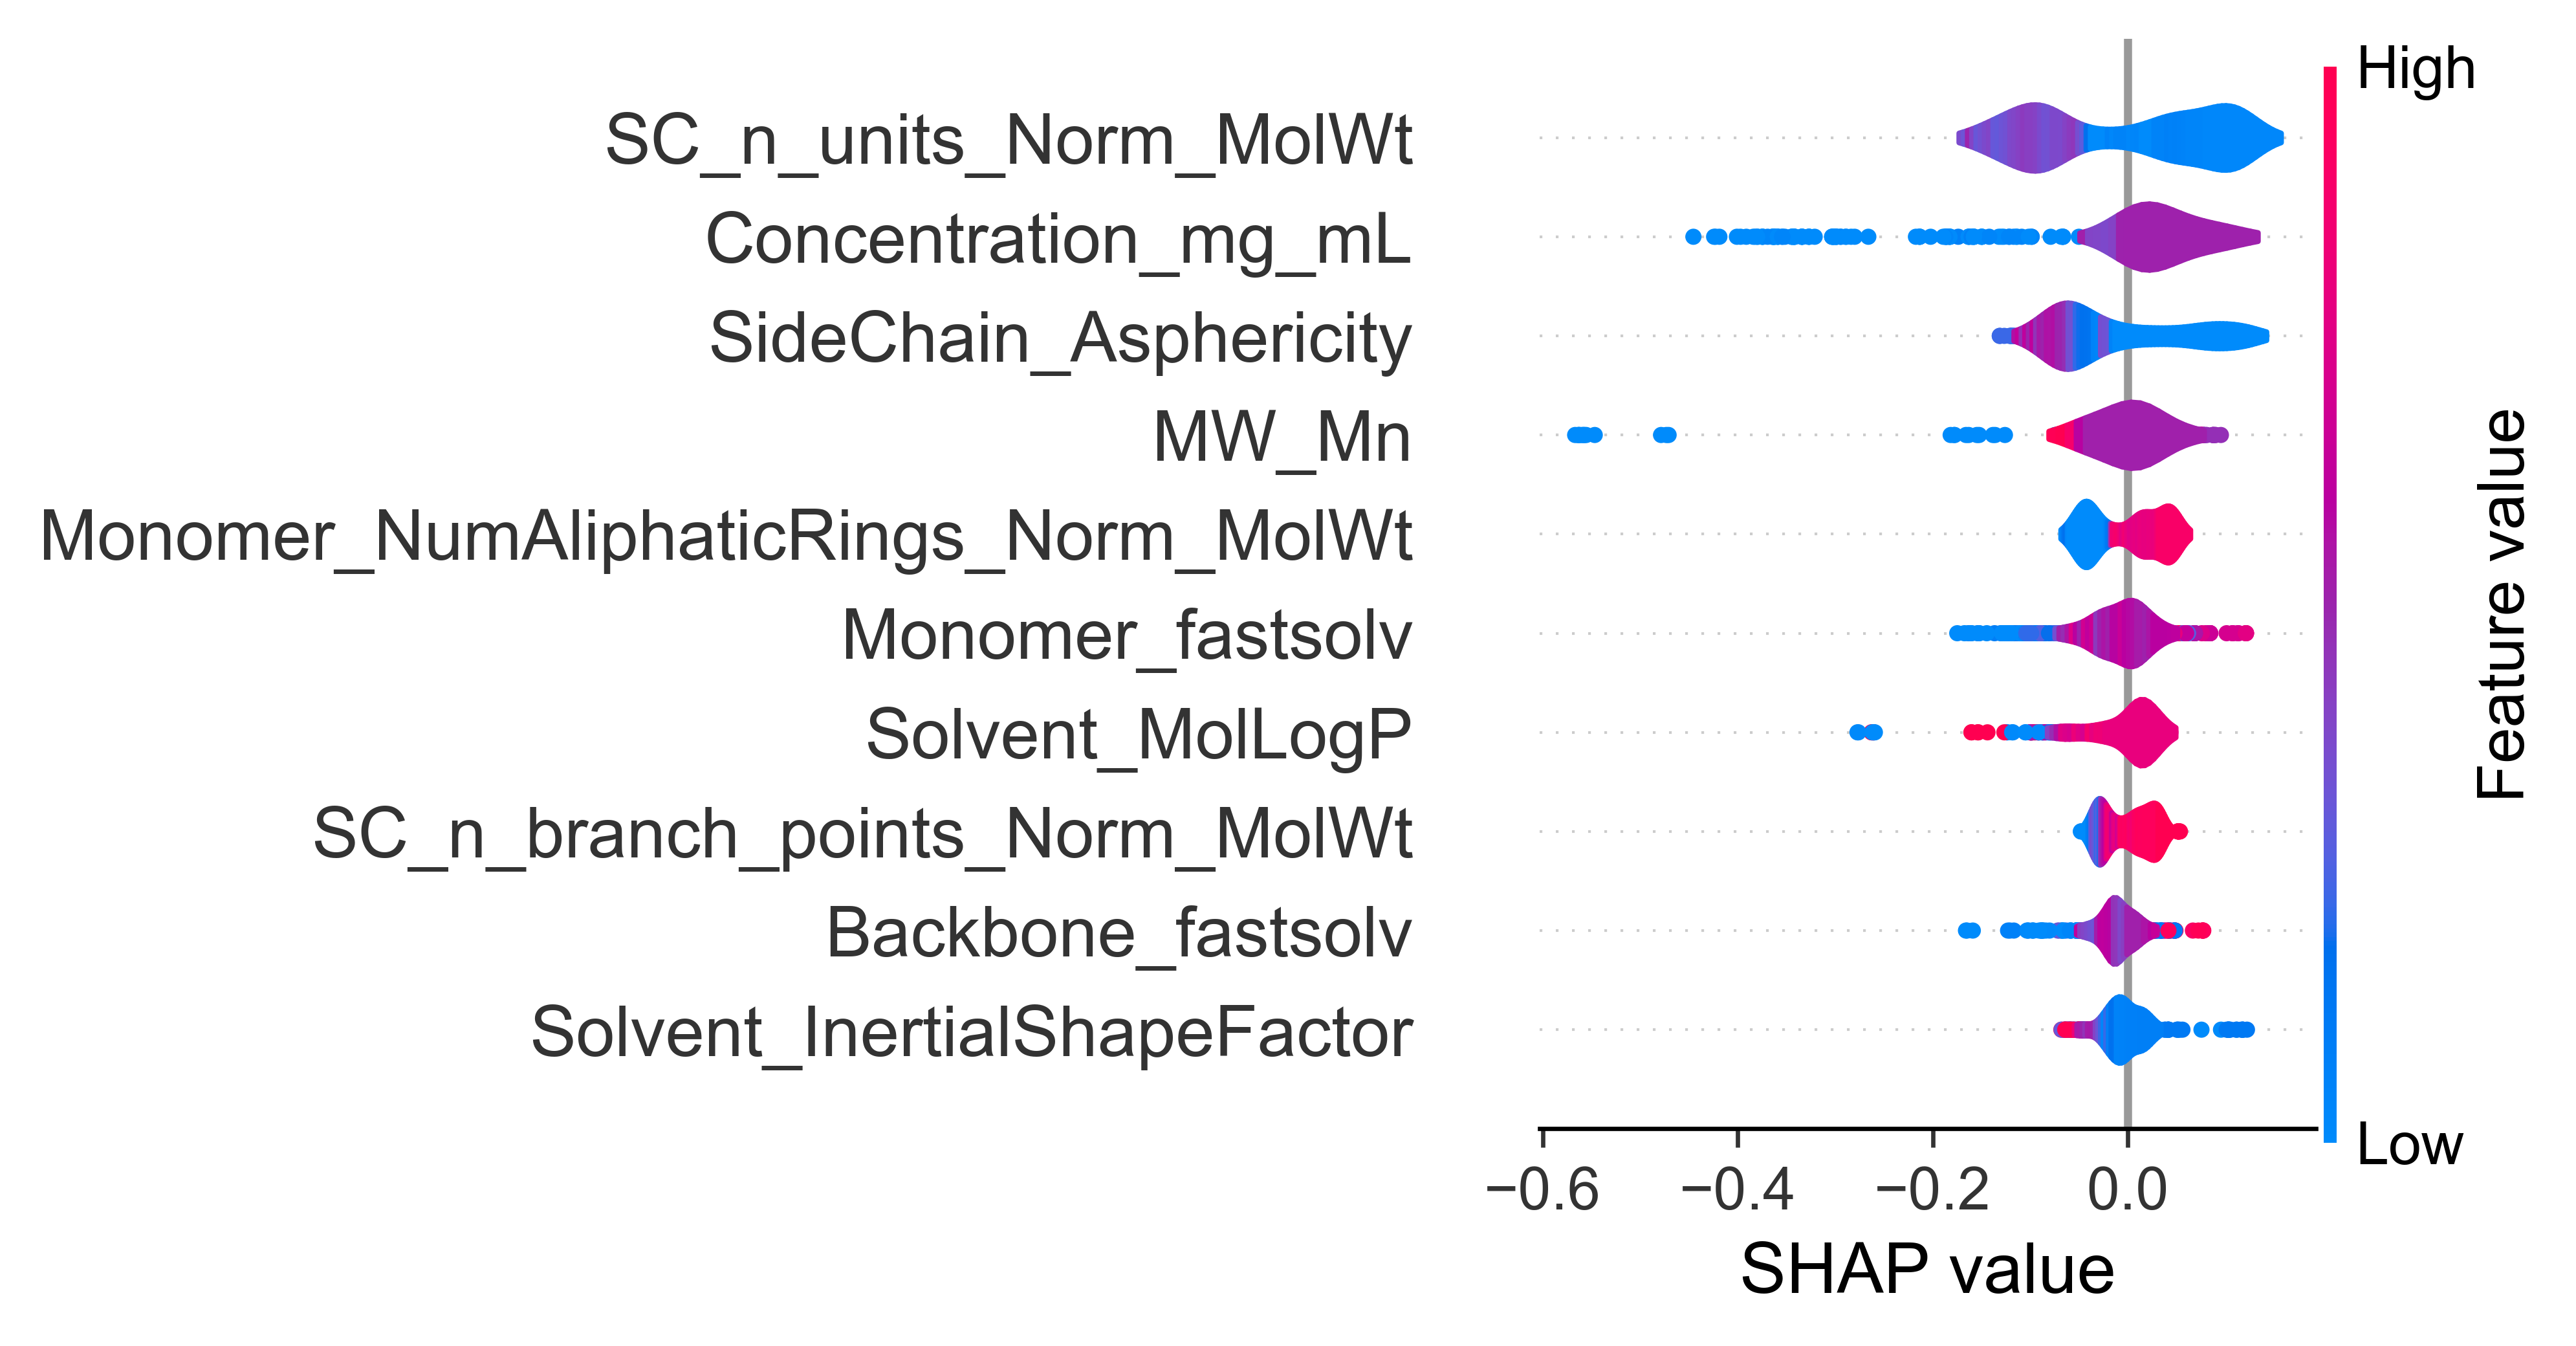

In [4]:
DROP_FEATURES = [
    'BB_conjugated_units_Norm_MolWt', 'R_ring_6', 'Monomer_NumHDonors_Norm_MolWt',
    'Monomer_NumHAcceptors_Norm_MolWt', 'SC_atoms_before_plus_after_CO_Norm_MolWt',
    'SideChain_Eccentricity', 'Backbone_Eccentricity', 'Monomer_Eccentricity',
    'R_atom_all', 'SC_bonds_CC_or_CO_Norm_MolWt', 'BB_C_atoms_Norm_MolWt',
    'Backbone_InertialShapeFactor', 'Solvent_Eccentricity', 'Solvent_TPSA',
    'SideChain_TPSA', 'R_ring_3', 'R_ring_1', 'SC_atoms_after_branching_CO_Norm_MolWt',
    'Monomer_InertialShapeFactor', 'SC_total_atoms_CO_Norm_MolWt', 'dG_solv_cosmo',
    'Monomer_NumSpiroAtoms_Norm_MolWt', 'Monomer_NumSaturatedRings_Norm_MolWt',
    'Monomer_NumBridgeheadAtoms_Norm_MolWt', 'MW_Mw', 'SC_C_atoms_Norm_MolWt',
    'BB_CeqC_bonds_Norm_MolWt', 'BB_CC_rotatable_bonds_Norm_MolWt',
    'SC_total_branches_Norm_MolWt', 'SC_atoms_before_branching_CO_Norm_MolWt',
    'Backbone_TPSA', 'BBminusSC_MolLogP', 'SideChain_InertialShapeFactor',
    'BB_rings_total_Norm_MolWt', 'Monomer_NumAromaticRings_Norm_MolWt',
    'SideChain_MolLogP',
]
RF_PARAMS = {
    'n_estimators': 1100, 'max_depth': 12, 'min_samples_leaf': 2,
    'min_samples_split': 2, 'max_features': 0.5,
    'class_weight': 'balanced', 'bootstrap': True, 'n_jobs': -1,
}

model_features = features_all.copy()
missing_mw = model_features[['MW_Mn', 'MW_Mw', 'PDI']].isna().sum()
if missing_mw.any():
    raise ValueError('The supplied feature workbook has missing molecular-weight values:\n' + missing_mw.to_string())
model_features = model_features.drop(columns=DROP_FEATURES, errors='ignore')
g_model = pd.to_numeric(metadata['abs_g_factor'], errors='coerce')
valid_model = g_model.notna()
X_shap = model_features.select_dtypes(include=[np.number]).loc[valid_model].reset_index(drop=True)
X_model = X_shap
y_model = (g_model.loc[valid_model] >= 0.001).astype(int).reset_index(drop=True)

final_clf = RandomForestClassifier(**RF_PARAMS, random_state=42)
final_clf.fit(X_shap, y_model)
raw_shap = shap.TreeExplainer(final_clf).shap_values(X_shap)
if isinstance(raw_shap, list):
    shap_values_pos = np.asarray(raw_shap[1], dtype=float)
elif np.asarray(raw_shap).ndim == 3:
    shap_values_pos = np.asarray(raw_shap, dtype=float)[:, :, 1]
else:
    shap_values_pos = np.asarray(raw_shap, dtype=float)

target_feature = 'SideChain_Asphericity'
max_display = 10
figure_size = (5.0, 3.6)
axes_position = [0.38, 0.12, 0.40, 0.78]
display_dpi = 500
save_dpi = 600

shap_matrix = np.asarray(shap_values_pos, dtype=float)
if shap_matrix.ndim != 2 or shap_matrix.shape != X_shap.shape:
    raise ValueError(f'Unexpected SHAP shape {shap_matrix.shape}; expected {X_shap.shape}.')
if target_feature not in X_shap.columns:
    raise KeyError(f"Feature '{target_feature}' was not found in X_shap.")

feature_importance = np.nansum(np.abs(shap_matrix), axis=0)
top_indices = np.argsort(feature_importance)[-max_display:][::-1]
top_features = X_shap.columns[top_indices].tolist()
if target_feature not in top_features:
    raise ValueError(f"'{target_feature}' is not among the top {max_display} features.")

X_plot_all = X_shap.loc[:, top_features].copy()
shap_plot_all = shap_matrix[:, top_indices].copy()
target_nonan_mask = X_shap[target_feature].notna().to_numpy()
X_plot_sc_nonan = X_shap.loc[target_nonan_mask, top_features].reset_index(drop=True).copy()
shap_plot_sc_nonan = shap_matrix[target_nonan_mask, :][:, top_indices].copy()

print('Fixed top-10 feature order:')
for rank, feature_name in enumerate(top_features, start=1):
    print(f'{rank:2d}. {feature_name}')
print('\nSideChain_Asphericity rows:')
print(' - all rows:', len(X_plot_all))
print(' - non-NaN rows:', len(X_plot_sc_nonan))
print(' - excluded NaN rows:', int((~target_nonan_mask).sum()))

def draw_fixed_violin(shap_values, features, xlim=None):
    """Original Figure2 cell-9 SHAP plotting function."""
    plt.close('all')
    plt.rcParams['figure.dpi'] = display_dpi
    plt.rcParams['savefig.dpi'] = save_dpi
    plt.rcParams['path.simplify'] = False
    np.random.seed(42)
    shap.plots.violin(
        shap_values,
        features=features,
        feature_names=features.columns,
        plot_type='violin',
        max_display=max_display,
        color='viridis',
        sort=False,
        show=False,
    )
    fig = plt.gcf()
    ax = fig.axes[0]
    fig.set_size_inches(*figure_size)
    ax.set_position(axes_position)
    ax.set_xlabel('SHAP value')
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.set_ylim(-1, max_display)
    return fig, ax

def figure_png_at_dpi(fig, dpi):
    fig.canvas.draw()
    tight_bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    pad_inches = plt.rcParams['savefig.pad_inches']
    buffer = BytesIO()
    fig.savefig(
        buffer, format='png', dpi=dpi, facecolor='white', transparent=False,
        bbox_inches='tight', pad_inches=pad_inches,
    )
    buffer.seek(0)
    image = PILImage.open(buffer).convert('RGBA').copy()
    return image, tight_bbox, pad_inches

fig_all, ax_all = draw_fixed_violin(shap_plot_all, X_plot_all)
shared_xlim = ax_all.get_xlim()
print('\nShared SHAP x-axis limits:', shared_xlim)
#display(fig_all)
target_y = max_display - 1 - top_features.index(target_feature)
axis_x_display = (ax_all.bbox.x0, ax_all.bbox.x1)
band_y_display = (
    ax_all.transData.transform((0, target_y - 0.49))[1],
    ax_all.transData.transform((0, target_y + 0.49))[1],
)
figure_dpi = fig_all.dpi
all_image, tight_bbox, pad_inches = figure_png_at_dpi(fig_all, save_dpi)
plt.close(fig_all)

fig_sc, ax_sc = draw_fixed_violin(shap_plot_sc_nonan, X_plot_sc_nonan, xlim=shared_xlim)
#display(fig_sc)
sc_image, sc_tight_bbox, sc_pad_inches = figure_png_at_dpi(fig_sc, save_dpi)
plt.close(fig_sc)

merged = np.asarray(all_image).copy()
replacement = np.asarray(sc_image)
if merged.shape != replacement.shape:
    raise ValueError(f'Reference image sizes differ: {merged.shape} vs {replacement.shape}.')
height, width = merged.shape[:2]

def display_x_to_tight_pixel(display_x):
    inches_from_tight_left = display_x / figure_dpi - tight_bbox.x0 + pad_inches
    return inches_from_tight_left * save_dpi

def display_y_to_tight_bottom_pixel(display_y):
    inches_from_tight_bottom = display_y / figure_dpi - tight_bbox.y0 + pad_inches
    return inches_from_tight_bottom * save_dpi

x_left = int(np.floor(display_x_to_tight_pixel(axis_x_display[0])))
x_right = int(np.ceil(display_x_to_tight_pixel(axis_x_display[1])))
row_top = int(np.floor(height - display_y_to_tight_bottom_pixel(band_y_display[1])))
row_bottom = int(np.ceil(height - display_y_to_tight_bottom_pixel(band_y_display[0])))
merged[row_top:row_bottom, x_left:x_right] = replacement[row_top:row_bottom, x_left:x_right]

outside_mask = np.ones((height, width), dtype=bool)
outside_mask[row_top:row_bottom, x_left:x_right] = False
outside_difference = np.abs(
    merged.astype(np.int16) - np.asarray(all_image).astype(np.int16)
)[outside_mask].max()
print(f'Merged pixel band: x={x_left}:{x_right}, y={row_top}:{row_bottom}')
print('Maximum pixel change outside the replaced band:', int(outside_difference))

figure6a_path = FIGURE_DIR / 'Figure6a.png'
PILImage.fromarray(merged).save(figure6a_path, dpi=(save_dpi, save_dpi))
display(NotebookImage(filename=str(figure6a_path)))


## Figure 6b — experimental FASTSOLV assembly map

Unique FASTSOLV positions: 227
Category
Strongly Chiral    80
Weakly Chiral       3
Isotropic          45
Aggregated         99
Name: count, dtype: int64


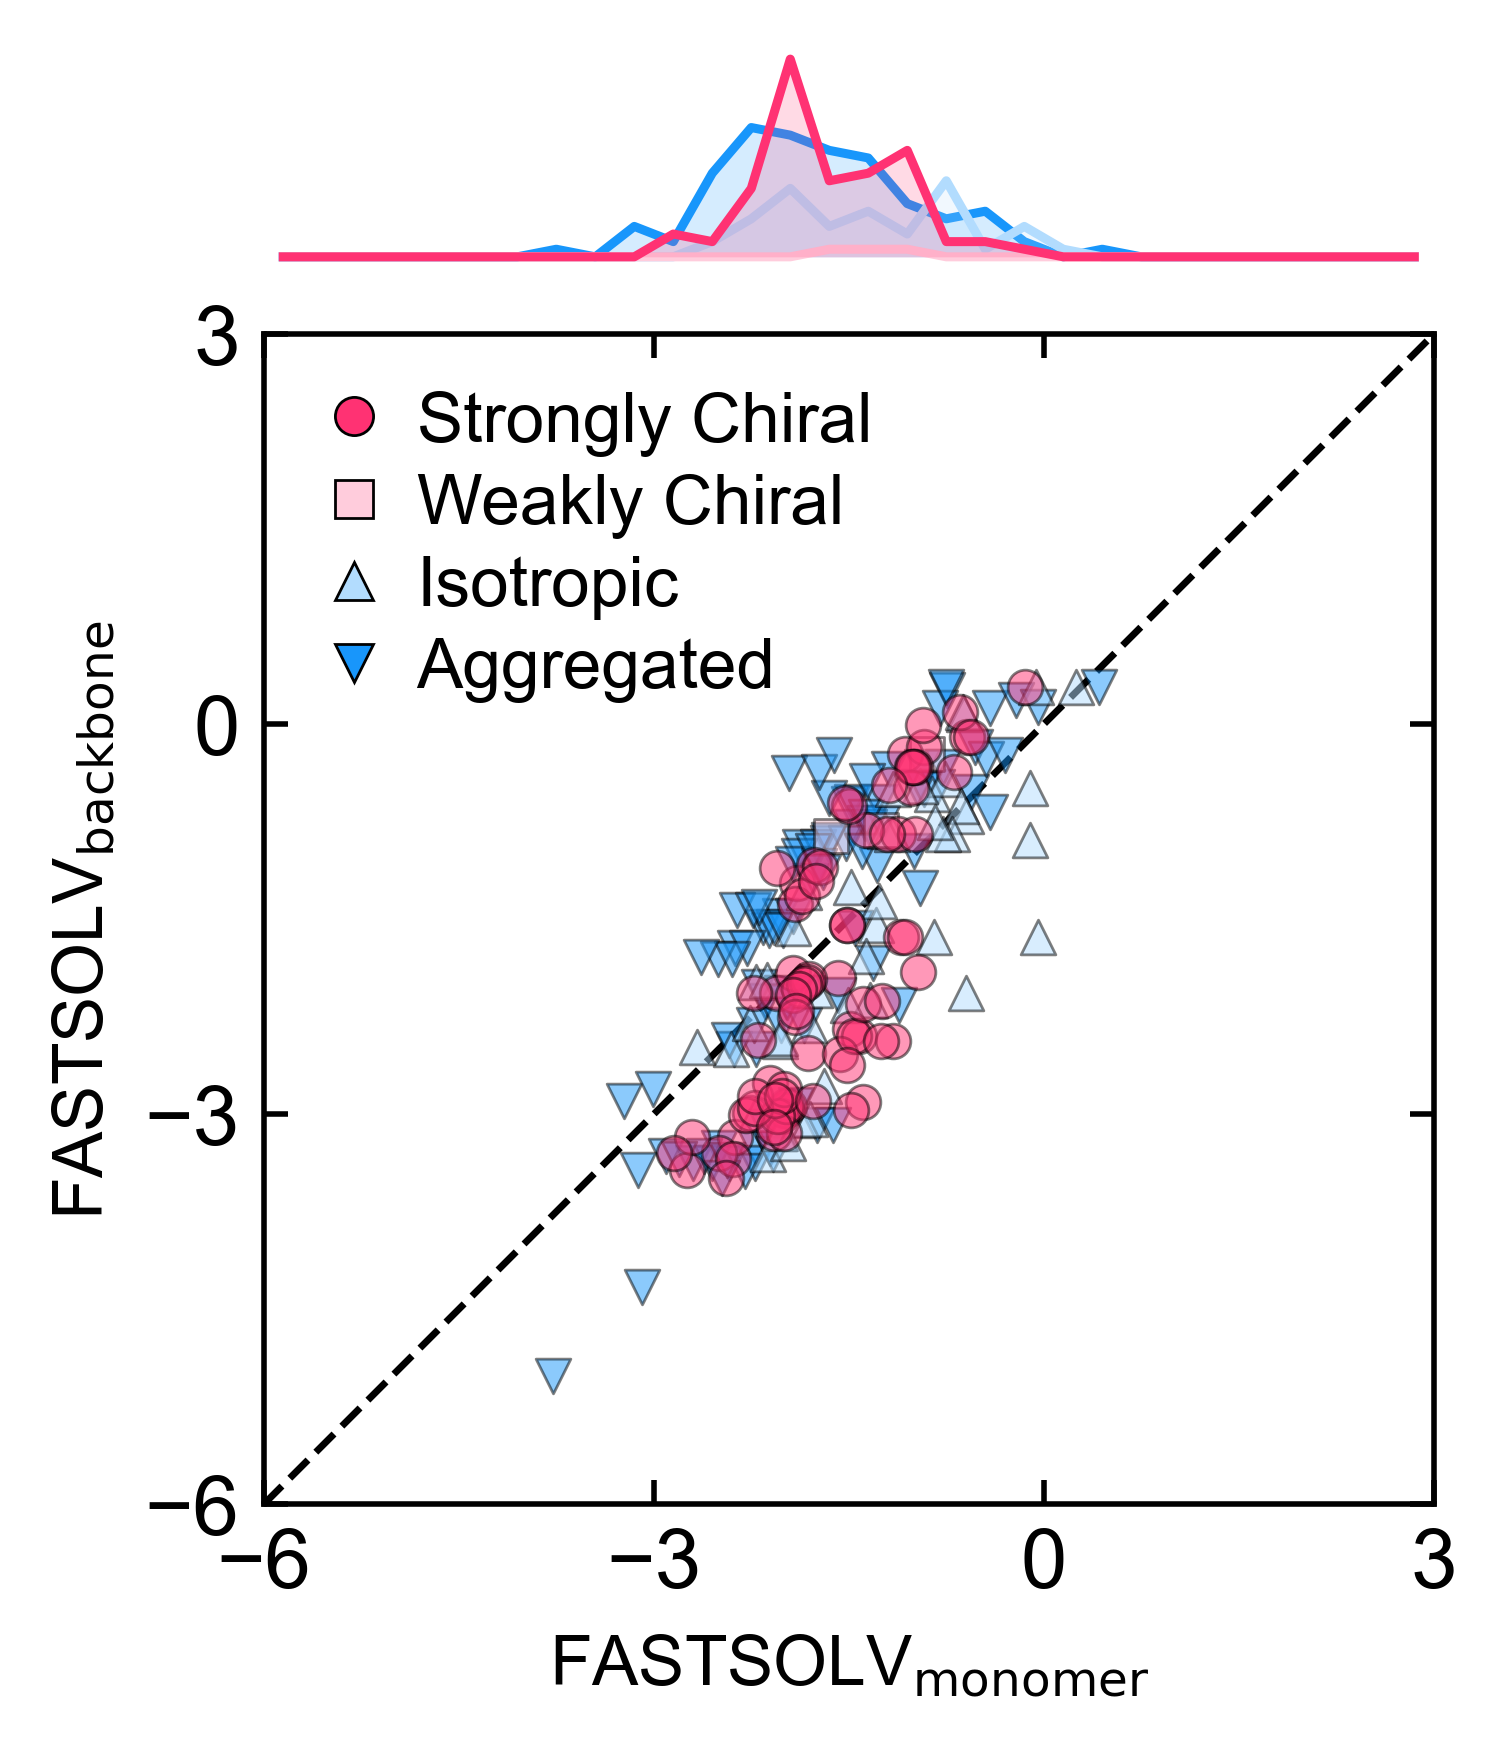

In [5]:
priority = {category: index for index, category in enumerate(CATEGORY_ORDER)}
d_unique_fastsolv = (
    d_all.assign(_priority=d_all['Category'].map(priority))
    .sort_values(['FASTSOLV_monomer', 'FASTSOLV_backbone', '_priority', 'RowPos'])
    .drop_duplicates(['FASTSOLV_monomer', 'FASTSOLV_backbone'], keep='first')
    .sort_values('RowPos').reset_index(drop=True)
)
if len(d_unique_fastsolv) != 227:
    raise ValueError(f'Expected 227 unique FASTSOLV positions, found {len(d_unique_fastsolv)}.')
print('Unique FASTSOLV positions:', len(d_unique_fastsolv))
print(d_unique_fastsolv['Category'].value_counts().reindex(CATEGORY_ORDER, fill_value=0))

monomer_xlim = (-6, 3)
backbone_ylim = (-6, 3)
fig = plt.figure(figsize=(3.0, 3.5), dpi=500)
grid = fig.add_gridspec(2, 1, height_ratios=[0.5, 3.0], hspace=0)
ax_hist = fig.add_subplot(grid[0])
ax = fig.add_subplot(grid[1], sharex=ax_hist)
edges = np.linspace(monomer_xlim[0], monomer_xlim[1], 31)
centers = (edges[:-1] + edges[1:]) / 2
for category in reversed(CATEGORY_ORDER):
    subset = d_unique_fastsolv.loc[d_unique_fastsolv['Category'].eq(category)]
    counts, _ = np.histogram(pd.to_numeric(subset['FASTSOLV_monomer'], errors='coerce').dropna(), bins=edges)
    ax_hist.plot(centers, counts, color=CATEGORY_TO_COLOR[category], linewidth=1.3, zorder=CATEGORY_TO_ZORDER[category])
    ax_hist.fill_between(centers, 0, counts, color=CATEGORY_TO_COLOR[category], alpha=0.18, linewidth=0,
                         zorder=CATEGORY_TO_ZORDER[category] - 0.5)
for spine in ax_hist.spines.values():
    spine.set_visible(False)
ax_hist.tick_params(axis='both', bottom=False, top=False, left=False, right=False,
                    labelbottom=False, labeltop=False, labelleft=False, labelright=False)
ax.plot([-6, 3], [-6, 3], color='black', linestyle='--', linewidth=1, zorder=1)
for category in reversed(CATEGORY_ORDER):
    subset = d_unique_fastsolv.loc[d_unique_fastsolv['Category'].eq(category)]
    ax.scatter(subset['FASTSOLV_monomer'], subset['FASTSOLV_backbone'], s=25,
               marker=CATEGORY_TO_MARKER[category], color=CATEGORY_TO_COLOR[category],
               edgecolor='black', linewidth=0.4, alpha=0.5, zorder=CATEGORY_TO_ZORDER[category])
ax.set_xlabel(r'FASTSOLV$_\mathrm{monomer}$')
ax.set_ylabel(r'FASTSOLV$_\mathrm{backbone}$')
ax.set_xlim(monomer_xlim); ax.set_ylim(backbone_ylim)
ax.set_xticks([-6, -3, 0, 3]); ax.set_yticks([-6, -3, 0, 3])
ax.set_box_aspect(1)
ax.tick_params(axis='both', direction='in', top=True, right=True, labelsize=12)
handles = [Line2D([0], [0], linestyle='none', marker=CATEGORY_TO_MARKER[c], markersize=5.5,
                  markerfacecolor=CATEGORY_TO_COLOR[c], markeredgecolor='black', markeredgewidth=0.4, label=c)
           for c in CATEGORY_ORDER]
ax.legend(handles=handles, loc='upper left', frameon=True, framealpha=0, edgecolor='none',
          fontsize=10, handlelength=1, handletextpad=0.4, borderpad=0.3, labelspacing=0.25)
fig.subplots_adjust(left=0.20, right=0.98, bottom=0.11, top=0.98)
fig.savefig(FIGURE_DIR / 'Figure6b.png', dpi=500, bbox_inches='tight')
plt.show()


## Figure 6c — RF prediction map in extended FASTSOLV space

The RF is trained on the labeled experimental v6x features. The v4x loop features are used for both prediction and plotting.

Points plotted: 3124
P_pred range: 0.000 to 0.988
Fraction P > 0.5: 0.284


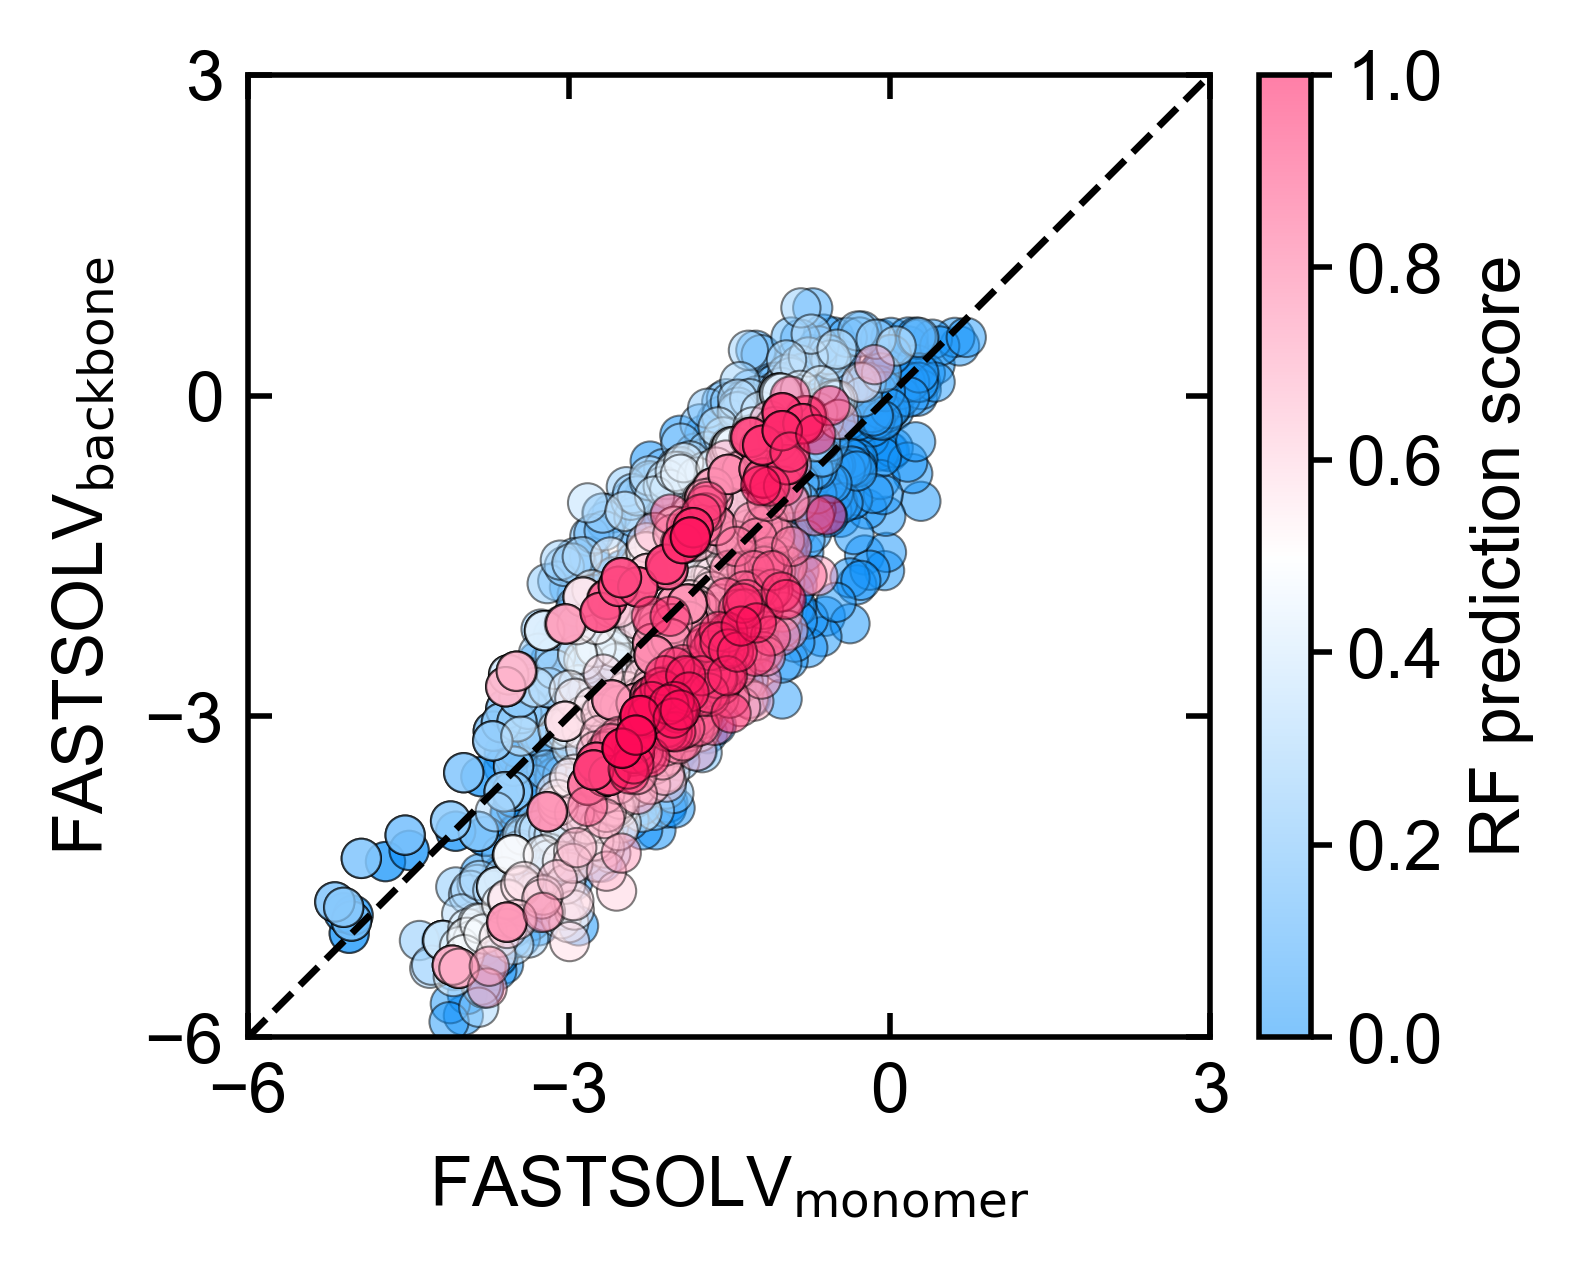

In [6]:
loop_feature_table = pd.read_excel(DATA_FILE, sheet_name='All_Combination_features')
if len(loop_feature_table) != 3124 or loop_feature_table['combination_id'].duplicated().any():
    raise ValueError('Expected 3124 uniquely keyed v4x all-combination rows.')
loop_features_v4x = loop_feature_table.drop(columns='combination_id').reset_index(drop=True)
loop_family_columns = [column for column in loop_features_v4x if column.startswith('family_')]
if not loop_features_v4x[loop_family_columns].sum(axis=1).eq(1).all():
    raise ValueError('Each v4x combination row must have exactly one family indicator.')

loop_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(**RF_PARAMS, random_state=42)),
])
loop_model.fit(X_model, y_model)
X_loop = (loop_features_v4x.drop(columns=DROP_FEATURES, errors='ignore')
          .select_dtypes(include=[np.number]).reindex(columns=X_model.columns))
loop_probability = loop_model.predict_proba(X_loop)[:, 1]
plot_loop = loop_features_v4x.copy()
plot_loop['P_pred'] = loop_probability

data = plot_loop[['Monomer_fastsolv', 'Backbone_fastsolv', 'P_pred']].apply(pd.to_numeric, errors='coerce').dropna()
data = data.loc[data['Monomer_fastsolv'].between(-6, 3) & data['Backbone_fastsolv'].between(-6, 3)]
data = data.sort_values('P_pred')
if len(data) != 3124:
    raise ValueError(f'Expected 3124 plotted loop points, found {len(data)}.')
print(f"Points plotted: {len(data)}\nP_pred range: {data['P_pred'].min():.3f} to {data['P_pred'].max():.3f}")
print(f"Fraction P > 0.5: {(data['P_pred'] > 0.5).mean():.3f}")

probability_cmap = LinearSegmentedColormap.from_list(
    'probability_blue_white_red', [(0, '#008BFB'), (0.5, '#FFFFFF'), (1, '#FF0051')], N=256
)
fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=500)
scatter = ax.scatter(data['Monomer_fastsolv'], data['Backbone_fastsolv'], c=data['P_pred'],
                     cmap=probability_cmap, s=32, edgecolor='black', linewidth=0.3,
                     vmin=0, vmax=1, zorder=2, alpha=0.5)
ax.plot([-6, 3], [-6, 3], color='black', linestyle='--', linewidth=1, zorder=3)
ax.set_xlabel(r'FASTSOLV$_\mathrm{monomer}$')
ax.set_ylabel(r'FASTSOLV$_\mathrm{backbone}$')
ax.set_xlim(-6, 3); ax.set_ylim(-6, 3)
ax.set_xticks([-6, -3, 0, 3]); ax.set_yticks([-6, -3, 0, 3])
ax.set_box_aspect(1)
ax.tick_params(axis='both', direction='in', top=True, right=True)
color_axis = ax.inset_axes([1.05, 0, 0.055, 1])
colorbar = fig.colorbar(scatter, cax=color_axis)
colorbar.set_label('RF prediction score', labelpad=4)
colorbar.ax.tick_params(axis='y', direction='out', length=3, width=0.8, pad=2)
colorbar.set_ticks(np.linspace(0, 1, 6))
fig.savefig(FIGURE_DIR / 'Figure6c.png', dpi=500, bbox_inches='tight')
plt.show()


## Figure 6d — stacked outcome fractions from Figure3z cell 12

This is the second plotted output from the old Figure3z cell 12.

Rows before FASTSOLV priority selection: 773
Rows after FASTSOLV priority selection: 227
Category
Strongly Chiral    80
Weakly Chiral       3
Isotropic          45
Aggregated         99
Name: count, dtype: int64

Counts by bin:


Category,Strongly Chiral,Weakly Chiral,Isotropic,Aggregated
Feature_bin,,,,
0–2,38,1,8,21
2–3,24,0,13,46
3–5,18,2,17,25
5+,0,0,7,7



Fractions by bin:


Category,Strongly Chiral,Weakly Chiral,Isotropic,Aggregated
Feature_bin,,,,
0–2,0.558824,0.014706,0.117647,0.308824
2–3,0.289157,0.000000,0.156627,0.554217
3–5,0.290323,0.032258,0.274194,0.403226
5+,0.000000,0.000000,0.500000,0.500000


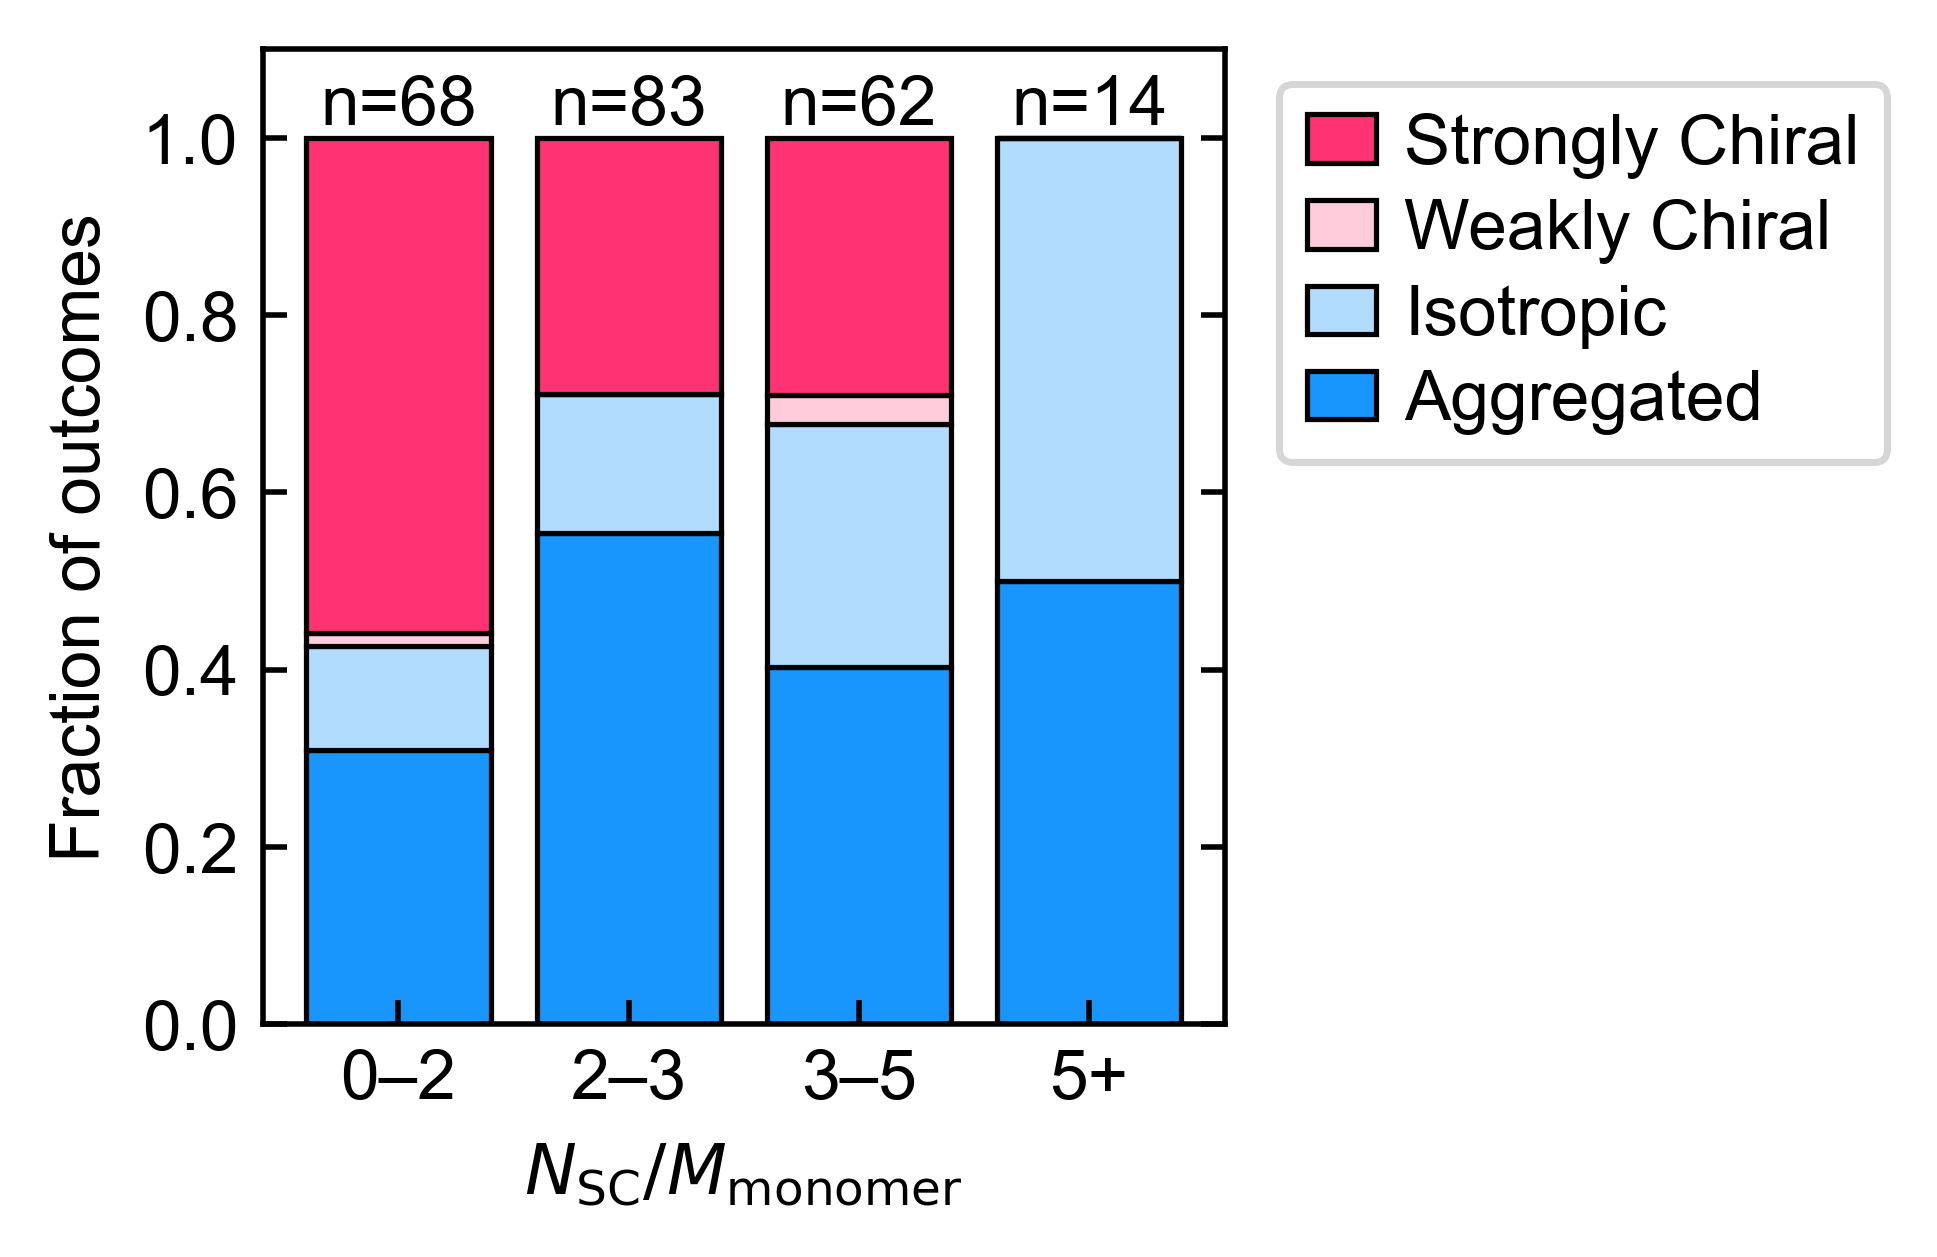

In [7]:
feature_col = 'SC_n_units_Norm_MolWt'
feature_label = r'$N_\mathrm{SC}/M_\mathrm{monomer}$'
point_size = 36
jitter_width = 0.2

CATEGORY_DISPLAY = {
    STRONG: 'Strongly Chiral',
    WEAK: 'Weakly Chiral',
    ISOTROPIC: 'Isotropic',
    AGGREGATION: 'Aggregated',
}
CATEGORY_TO_Y = {STRONG: 3, WEAK: 2, ISOTROPIC: 1, AGGREGATION: 0}
category_priority = {category: i for i, category in enumerate(CATEGORY_ORDER)}

required_cols = [feature_col, 'Category', 'FASTSOLV_backbone', 'FASTSOLV_monomer']
missing_cols = [column for column in required_cols if column not in d_all_feature.columns]
if missing_cols:
    raise KeyError(f'Missing columns: {missing_cols}')

cols_to_keep = required_cols + (['RowPos'] if 'RowPos' in d_all_feature.columns else [])
plot_feature_df = d_all_feature[cols_to_keep].copy()
for column in [feature_col, 'FASTSOLV_backbone', 'FASTSOLV_monomer']:
    plot_feature_df[column] = pd.to_numeric(plot_feature_df[column], errors='coerce')
plot_feature_df = (
    plot_feature_df.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=required_cols)
    .loc[lambda data: data['Category'].isin(CATEGORY_ORDER)]
    .copy()
)
plot_feature_df['_Category_priority'] = plot_feature_df['Category'].map(category_priority)
sort_columns = ['FASTSOLV_backbone', 'FASTSOLV_monomer', '_Category_priority']
ascending = [True, True, True]
if 'RowPos' in plot_feature_df.columns:
    sort_columns.append('RowPos')
    ascending.append(True)
n_before_priority = len(plot_feature_df)
plot_feature_df = (
    plot_feature_df.sort_values(sort_columns, ascending=ascending)
    .drop_duplicates(['FASTSOLV_backbone', 'FASTSOLV_monomer'], keep='first')
)
if 'RowPos' in plot_feature_df.columns:
    plot_feature_df = plot_feature_df.sort_values('RowPos').reset_index(drop=True)
else:
    plot_feature_df = plot_feature_df.reset_index(drop=True)

print('Rows before FASTSOLV priority selection:', n_before_priority)
print('Rows after FASTSOLV priority selection:', len(plot_feature_df))
print(plot_feature_df['Category'].value_counts().reindex(CATEGORY_ORDER, fill_value=0))

bin_edges = [0, 2, 3, 5, np.inf]
bin_labels = ['0–2', '2–3', '3–5', '5+']

bar_df = plot_feature_df.copy()
bar_df['Feature_bin'] = pd.cut(
    bar_df[feature_col],
    bins=bin_edges,
    labels=bin_labels,
    right=False,
    include_lowest=True,
)
bar_df = bar_df.dropna(subset=['Feature_bin'])

counts = pd.crosstab(bar_df['Feature_bin'], bar_df['Category'])
counts = counts.reindex(index=bin_labels, columns=CATEGORY_ORDER, fill_value=0)
n_per_bin = counts.sum(axis=1)
fractions = counts.div(n_per_bin.replace(0, np.nan), axis=0).fillna(0)

print('\nCounts by bin:')
display(counts)
print('\nFractions by bin:')
display(fractions)

fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=500)
x = np.arange(len(bin_labels))
bottom = np.zeros(len(bin_labels))

for category in reversed(CATEGORY_ORDER):
    values = fractions[category].to_numpy()
    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.8,
        color=CATEGORY_TO_COLOR[category],
        edgecolor='black',
        linewidth=0.75,
    )
    bottom += values

for index, count in enumerate(n_per_bin):
    ax.text(index, 1.0, f'n={int(count)}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel(feature_label)
ax.set_ylabel('Fraction of outcomes')
ax.set_xticks(x)
ax.set_xticklabels(bin_labels)
ax.set_ylim(0, 1.1)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.tick_params(axis='both', which='both', direction='in', top=False, right=True)

legend_handles = [
    Patch(
        facecolor=CATEGORY_TO_COLOR[category],
        edgecolor='black',
        linewidth=0.75,
        label=CATEGORY_DISPLAY[category],
    )
    for category in CATEGORY_ORDER
]
ax.legend(
    handles=legend_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    frameon=True,
    fontsize=10,
    handlelength=1.0,
    handletextpad=0.4,
    borderpad=0.4,
    labelspacing=0.3,
)
fig.subplots_adjust(left=0.20, right=0.75, bottom=0.18, top=0.96)
fig.savefig(FIGURE_DIR / 'Figure6d.png', dpi=500, bbox_inches='tight')
plt.show()


## Figure 6e — FASTSOLV descriptors by polymer family

,New_family,n,backbone_mean,backbone_error,monomer_mean,monomer_error
0,NDI,15.0,-3.061600,0.394619,-2.356707,0.280565
1,PM7,1.0,-2.969018,0.000000,-1.481771,0.000000
2,IDT,1.0,-2.900188,0.000000,-1.773869,0.000000
3,PII,15.0,-2.805561,0.366298,-1.896753,0.295976
4,DPP,12.0,-2.729595,0.250138,-1.845267,0.402014
5,Polyfluorene,3.0,-2.063091,0.135378,-1.199971,0.214090
6,PTQ,8.0,-1.577405,0.609250,-1.495881,0.467695
7,PE/ProDOT,11.0,-0.696234,0.514883,-1.353336,0.458547
8,Thiophene,19.0,-0.593116,0.442749,-1.173143,0.495587


Overall monomer mean: -1.6699
Overall monomer STD: 0.5692


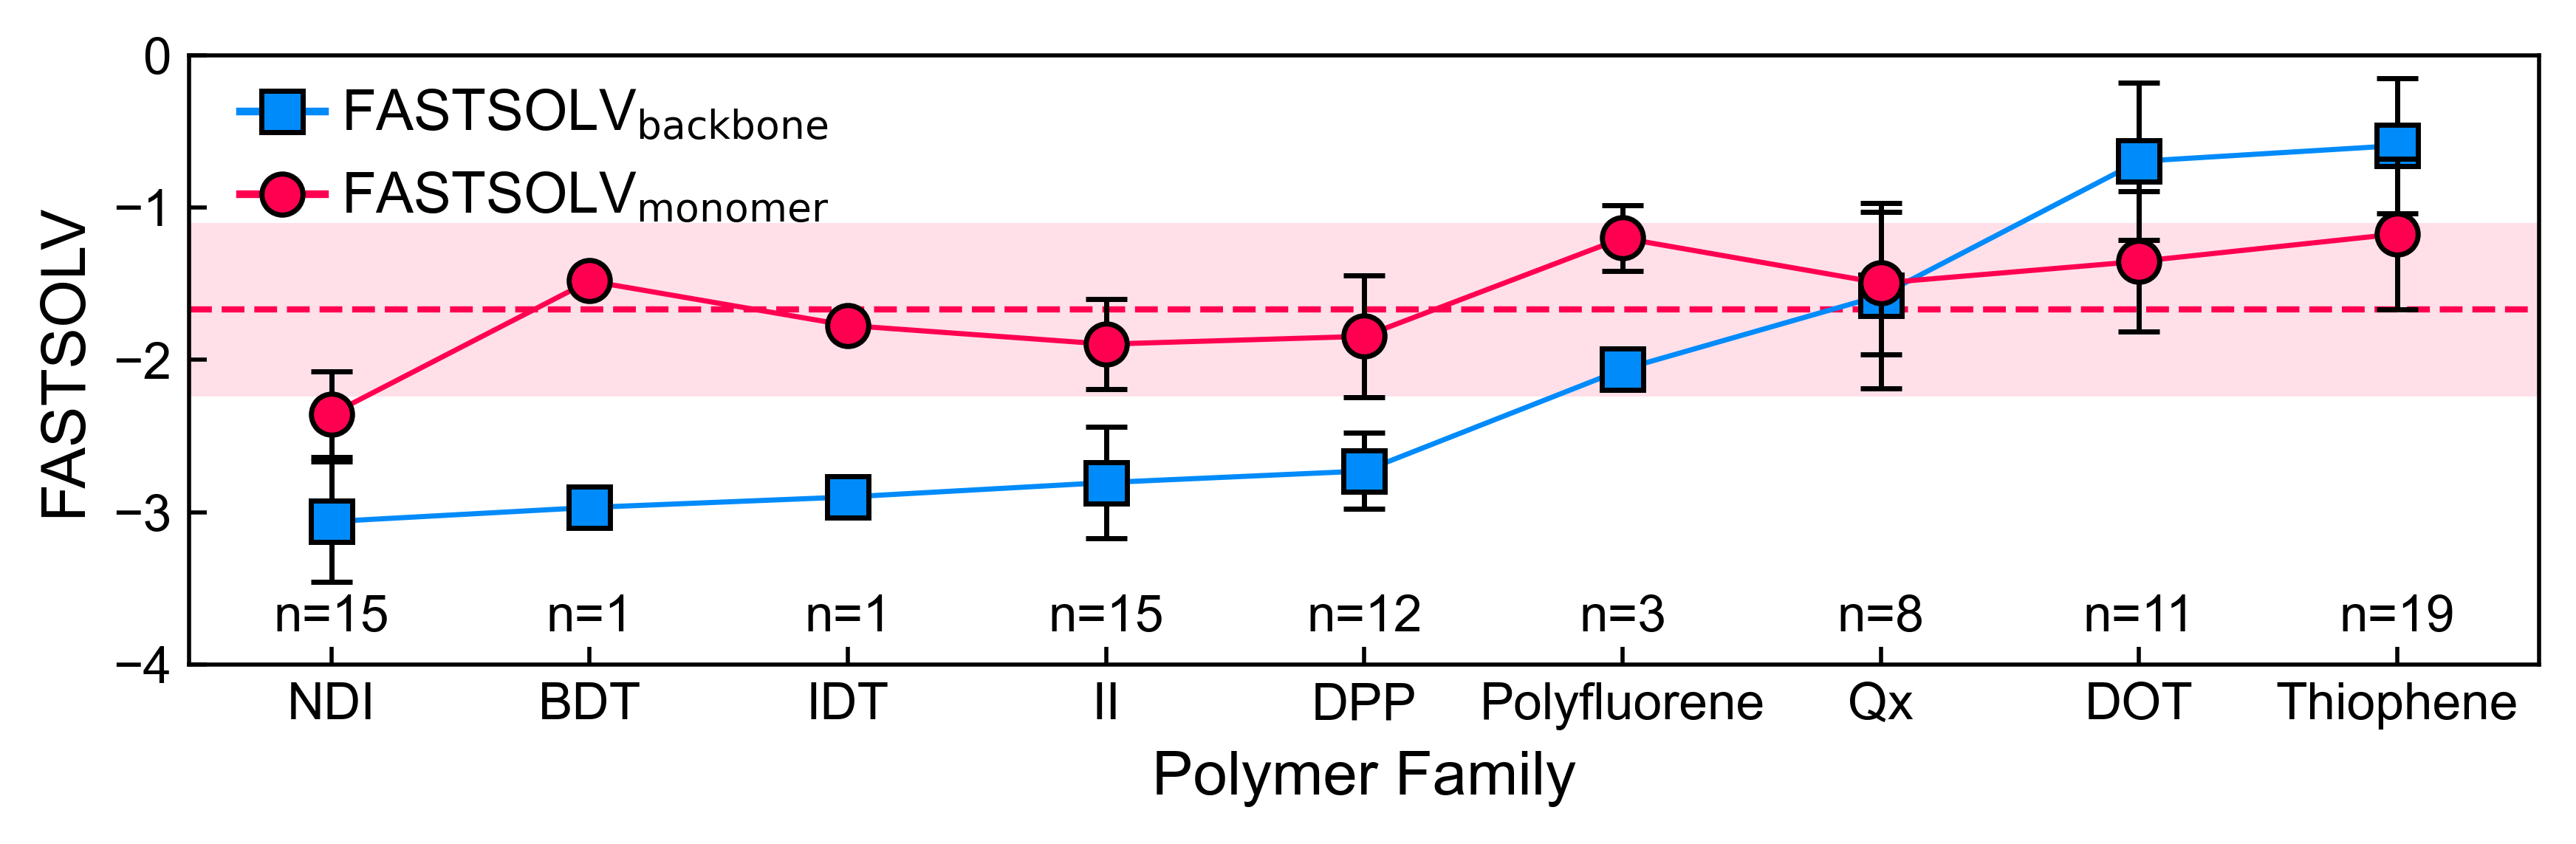

In [8]:
family_data = d_all_feature.copy()
family_data['New_family'] = metadata.loc[family_data['RowPos'], 'Family'].to_numpy()
family_data['New_family'] = family_data['New_family'].str.replace(r' family$', '', regex=True).replace({
    'polyfluorene': 'Polyfluorene', 'ladder': 'Ladder'
})
family_data = family_data.loc[
    family_data['Assemble Type'].astype('string').str.strip().str.lower().eq('c')
    & family_data['New_family'].ne('Ladder')
].replace([np.inf, -np.inf], np.nan).dropna(
    subset=['New_family', 'Polymer name', 'Solvent', 'FASTSOLV_backbone', 'FASTSOLV_monomer']
).copy()
family_data['_Polymer_key'] = family_data['Polymer name'].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True).str.lower()
family_data['_Solvent_key'] = family_data['Solvent'].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True).str.lower()
family_pairs = (family_data.sort_values('RowPos')
                .drop_duplicates(['New_family', '_Polymer_key', '_Solvent_key'], keep='first'))
family_order = ['NDI', 'PII', 'DPP', 'IDT', 'Polyfluorene', 'PM7', 'PTQ', 'TPT', 'PE/ProDOT', 'Thiophene']
summary = (family_pairs.groupby('New_family', observed=True)
           .agg(n=('FASTSOLV_monomer', 'size'), backbone_mean=('FASTSOLV_backbone', 'mean'),
                backbone_error=('FASTSOLV_backbone', 'std'), monomer_mean=('FASTSOLV_monomer', 'mean'),
                monomer_error=('FASTSOLV_monomer', 'std'))
           .reindex(family_order).dropna(subset=['backbone_mean', 'monomer_mean'], how='all')
           .reset_index().sort_values('backbone_mean').reset_index(drop=True))
summary[['backbone_error', 'monomer_error']] = summary[['backbone_error', 'monomer_error']].fillna(0)
display(summary)
monomer_values = family_pairs['FASTSOLV_monomer'].dropna().to_numpy(float)
overall_mean = monomer_values.mean()
overall_std = monomer_values.std(ddof=1) if len(monomer_values) > 1 else 0
print(f'Overall monomer mean: {overall_mean:.4f}')
print(f'Overall monomer STD: {overall_std:.4f}')

display_labels = {'NDI': 'NDI', 'PII': 'II', 'DPP': 'DPP', 'IDT': 'IDT',
                  'Polyfluorene': 'Polyfluorene', 'PM7': 'BDT', 'PTQ': 'Qx',
                  'TPT': 'TPT', 'PE/ProDOT': 'DOT', 'Thiophene': 'Thiophene'}
backbone_color, monomer_color = cmap_outcome(0.0), cmap_outcome(1.0)
fig, ax = plt.subplots(figsize=(7.4, 2.5), dpi=500)
x = np.arange(len(summary), dtype=float)
ax.axhspan(overall_mean - overall_std, overall_mean + overall_std, facecolor=monomer_color,
           alpha=0.12, edgecolor='none', zorder=0)
ax.axhline(overall_mean, color=monomer_color, linestyle='--', linewidth=1.2, zorder=1)
backbone = ax.errorbar(x, summary['backbone_mean'], yerr=summary['backbone_error'], fmt='s-',
                       linewidth=1, color=backbone_color, ecolor='black', markersize=8,
                       markeredgecolor='black', markeredgewidth=1, elinewidth=1, capsize=4, capthick=1, zorder=3)
monomer = ax.errorbar(x, summary['monomer_mean'], yerr=summary['monomer_error'], fmt='o-',
                      linewidth=1, color=monomer_color, ecolor='black', markersize=8,
                      markeredgecolor='black', markeredgewidth=1, elinewidth=1, capsize=4, capthick=1, zorder=4)
for cap in [*backbone[1], *monomer[1]]:
    cap.set_markeredgewidth(1)
for index, row in summary.iterrows():
    ax.text(x[index], -3.85, f"n={int(row['n'])}", ha='center', va='bottom', fontsize=10)
ax.set_xticks(x, [display_labels.get(name, name) for name in summary['New_family']], fontsize=10)
ax.set_xlabel('Polymer Family', fontsize=12)
ax.set_ylabel('FASTSOLV', fontsize=12)
ax.set_ylim(-4, 0); ax.set_yticks(np.arange(-4, 0.1, 1))
ax.set_xlim(-0.55, len(x) - 1 + 0.55)
ax.tick_params(axis='both', direction='in', labelsize=10)
handles = [
    Line2D([0], [0], color=backbone_color, marker='s', markeredgecolor='black', markersize=8,
           label=r'FASTSOLV$_\mathrm{backbone}$'),
    Line2D([0], [0], color=monomer_color, marker='o', markeredgecolor='black', markersize=8,
           label=r'FASTSOLV$_\mathrm{monomer}$'),
]
ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(0, 1.03), frameon=False,
          fontsize=11, handlelength=1.5, handletextpad=0.3)
fig.subplots_adjust(left=0.12, right=0.98, bottom=0.31, top=0.97)
fig.savefig(FIGURE_DIR / 'Figure6e.png', dpi=500, bbox_inches='tight')
plt.show()
